<a href="https://colab.research.google.com/github/Gokulanandh-p/Gokulanandh-p/blob/main/Google_Play_Store_Apps_Analysis_by_Gokul_Anandh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 8197 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------    

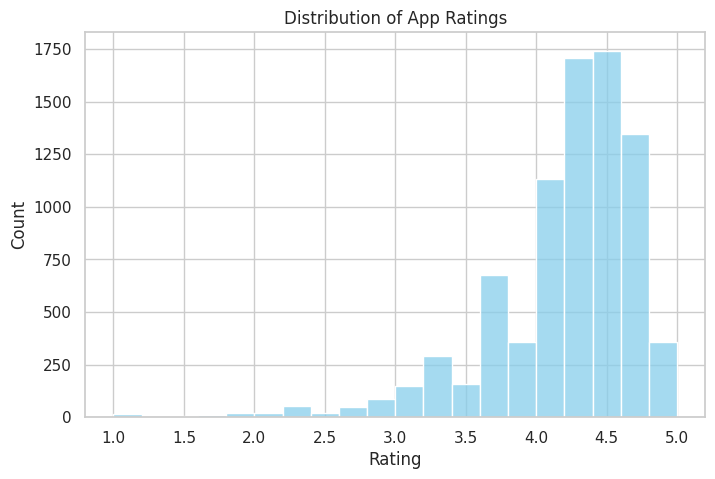

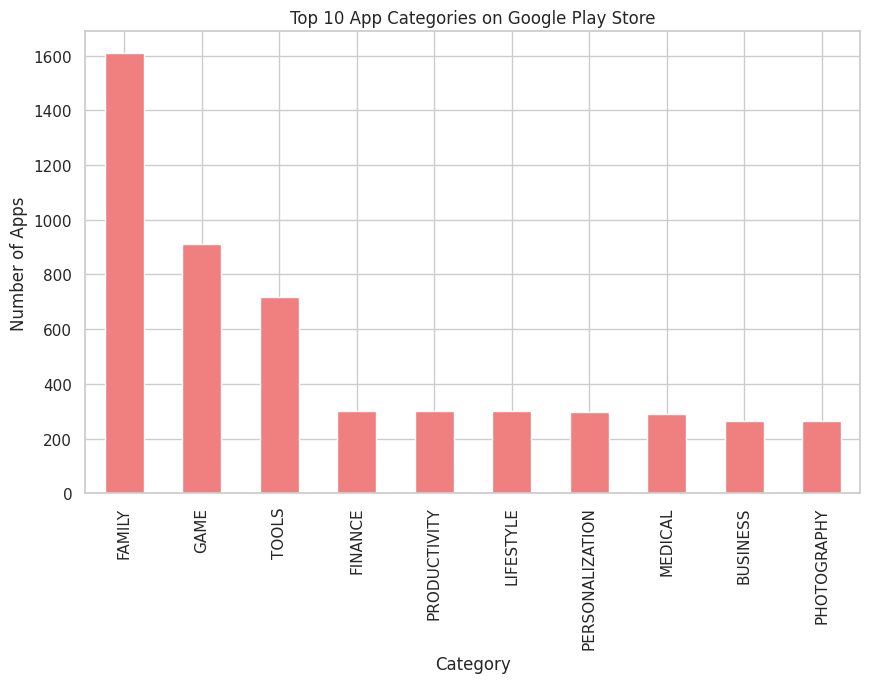

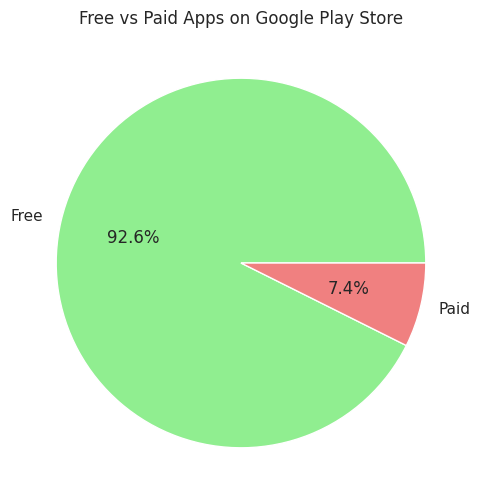

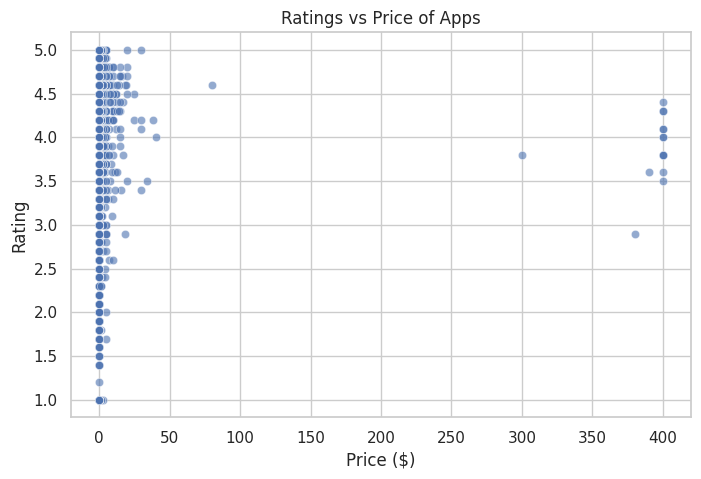

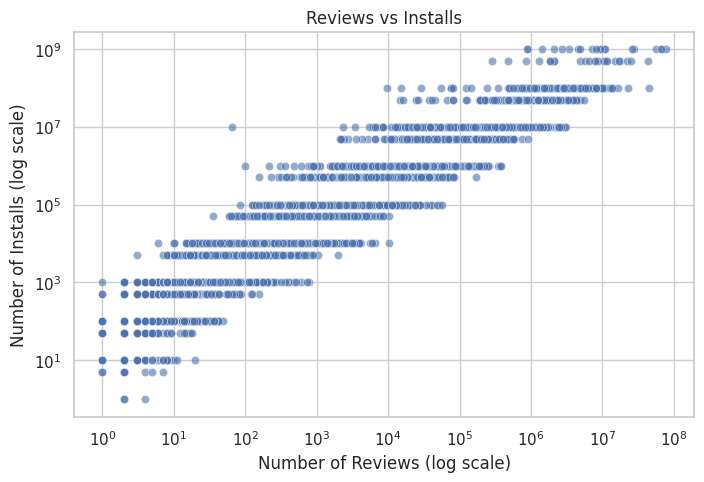

/tmp/ipython-input-3196139050.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='coolwarm')


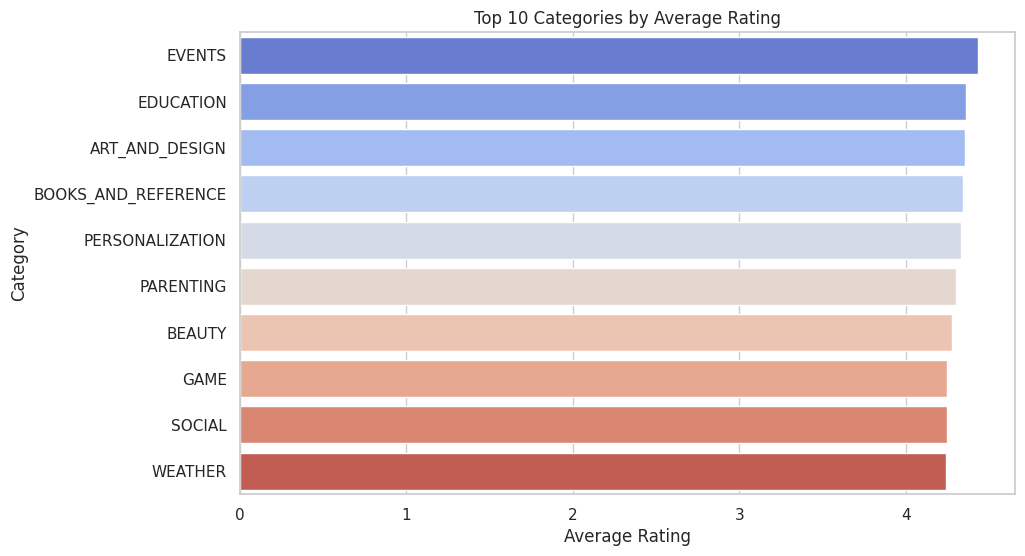

In [12]:
import pandas as pd

# Load CSV directly from the local Colab environment
df = pd.read_csv('/content/googleplaystore.csv')

# View first few rows
df.head()

# Show the shape (rows, columns)
df.shape

# Check basic info about each column
df.info()

# Display summary statistics (only for numeric columns)
df.describe()
# Count missing values in each column
df.isnull().sum()

# Remove duplicate app names
df.drop_duplicates(subset='App', inplace=True)

# Remove rows where Rating is missing
df = df[df['Rating'].notna()]

# Confirm cleaning worked
df.info()

# Clean 'Installs' column
df['Installs'] = df['Installs'].str.replace('+','').str.replace(',','')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Clean 'Price' column
df['Price'] = df['Price'].str.replace('$','')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Convert 'Reviews' column to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Drop rows that became NaN after conversion
df.dropna(subset=['Installs', 'Price', 'Reviews'], inplace=True)

# Recheck
df.info()
df.head()
# --------------------------------------------
# STEP 5: Exploratory Data Analysis (EDA)
# Google Play Store Apps - by Gokul Anandh
# --------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean visual style
sns.set(style="whitegrid")

# ---------------------------
# 5.2 Distribution of App Ratings
# ---------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20, color='skyblue')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# ---------------------------
# 5.3 Top 10 App Categories
# ---------------------------
plt.figure(figsize=(10,6))
df['Category'].value_counts().head(10).plot(kind='bar', color='lightcoral')
plt.title('Top 10 App Categories on Google Play Store')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.show()

# ---------------------------
# 5.4 Free vs Paid Apps
# ---------------------------
plt.figure(figsize=(6,6))
df['Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen','lightcoral'])
plt.title('Free vs Paid Apps on Google Play Store')
plt.ylabel('')
plt.show()

# ---------------------------
# 5.5 Ratings vs Price
# ---------------------------
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Price', y='Rating', alpha=0.6)
plt.title('Ratings vs Price of Apps')
plt.xlabel('Price ($)')
plt.ylabel('Rating')
plt.show()

# ---------------------------
# 5.6 Reviews vs Installs
# ---------------------------
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Reviews', y='Installs', alpha=0.6)
plt.title('Reviews vs Installs')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Reviews (log scale)')
plt.ylabel('Number of Installs (log scale)')
plt.show()

# ---------------------------
# 5.7 Average Rating by Category
# ---------------------------
plt.figure(figsize=(10,6))
avg_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='coolwarm')
plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.show()


# 📱 Visual Analysis of Google Play Store Apps
### by Gokul Anandh Palanisamy
## 🎯 Introduction

This project explores apps available on the **Google Play Store** to identify patterns in categories, ratings, pricing, and installs.

The goal is to uncover insights into:
- Which categories dominate the app market  
- How ratings differ between free and paid apps  
- Whether price impacts user satisfaction  
- Which app types users engage with most  

This project is part of my **Data Analytics learning journey**, showcasing my ability to work with real datasets, clean data, visualize trends, and communicate insights effectively.
## 📂 Step 1: Load the Dataset
We use the Google Play Store dataset from Kaggle.
## 🧹 Step 2: Data Cleaning
Before analyzing, we clean and format the dataset by:
- Removing duplicates  
- Handling missing values  
- Converting text columns like `Price` and `Installs` to numeric format  
- Ensuring consistent data types  
## 📊 Step 3: Exploratory Data Analysis (EDA)
We explore the dataset visually to understand trends and relationships.
## 💡 Step 4: Key Insights

- "Family", "Game", and "Tools" categories dominate in volume.  
- Over **90% of apps are free**, showing freemium model popularity.  
- Most apps maintain ratings between **4.0 – 4.5**, showing high user satisfaction.  
- Paid apps don’t always get higher ratings.  
- More reviews generally mean more installs — engagement drives success.  
- “Education” and “Lifestyle” apps are among the highest-rated categories.
## 🏁 Step 5: Conclusion

This analysis highlights how app category, pricing, and engagement influence success on the Google Play Store.

It demonstrates skills in:
- Data Cleaning (Pandas)  
- Data Visualization (Matplotlib & Seaborn)  
- Business Insight Generation  

Next, I plan to build a **Tableau dashboard** for this dataset to further enhance interactivity and storytelling.
